In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [5]:
load_dotenv()

True

In [6]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [7]:
subgraph_llm = ChatGroq(model="openai/gpt-oss-120b")
parent_llm = ChatGroq(model="openai/gpt-oss-120b")

In [8]:
def translate_text(state: ParentState):
    prompt = f"""Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.
    Text:
    {state["answer_eng"]}
    """.strip()
    translated_text = subgraph_llm.invoke(prompt).content
    return {'answer_hin': translated_text}

In [9]:
subgraph_builder = StateGraph(ParentState)
subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()

In [11]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are helpful assistant. Answer clearly. \n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate",subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate',END)

graph = parent_builder.compile()


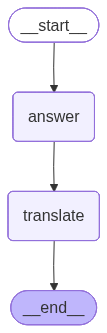

In [13]:
graph

In [14]:
graph.invoke({'question': 'whatis agentic engineering'})

{'question': 'whatis agentic engineering',
 'answer_eng': '**Agentic engineering** is a term that has emerged mainly in the AI‑safety and alignment community (and, to a lesser extent, in organizational‑psychology literature) to describe the practice of **designing, building, and controlling artificial agents so that their “agency” (goal‑directed, purposeful behavior) is shaped in a predictable, safe, and beneficial way**.\n\nBelow is a clear, structured overview of what the phrase means, why it matters, and how it is pursued.\n\n---\n\n## 1. Core Idea\n\n| Concept | What it means in this context |\n|---------|------------------------------|\n| **Agent** | An autonomous system that can perceive its environment, form internal states (goals, beliefs, preferences), and take actions to influence that environment. In AI, this is usually a reinforcement‑learning (RL) or planning‑based model, a language model with tool‑use, a robotics controller, etc. |\n| **Agency** | The capacity to act *int